# From netCDF to numpy Array (MPI-ESM1-2-HR)
# Precipitation
# SSP 245 (original)

## 1. Environment

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

/Users/peyaudv/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
def get_slopes_and_pvalue(wp_meanseason):

    wp_meanseason_hist = wp_meanseason[:86,:,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanseason.shape[3]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanseason.shape[2]):
            for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanseason_hist.shape[0]), wp_meanseason_hist[:,season,j,i])
                origin_hist[season][j][i] = linregress_hist.intercept
                slope_hist[season][j][i] = linregress_hist.slope
                pvalue_hist[season][j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

In [3]:
# Which Computer ?
#path_DIR = '/bettik/beaumetj/'  # On dahu
path_DIR = '/Users/peyaudv/Glaciers/MAR_GCMs/' # Local pc perso
path_IMG = path_DIR+'SavedFigures/'

In [4]:
# Where are the data files?
name_GCM = 'MPI-ESM1-2-HR'
#name_GCMlon = 'MPI-ESM1-2-LR'
dirGCM   = 'MPI-ESM1-2-HR'
dirMARGCM= 'MPI-ESM1-2-HR'
nameGCMinMARfile= 'MPI-ESM'
realizati= 'r1i1p1f1'
#name_GCM = 'EC-Earth3' # seuls copie en local sur le MAC
#dirMARGCM= 'EC-Earth3'
#realizati= 'r25i1p1f1'


#scenario = 'SSP245' #'HIST' #'SSP245' #'SSP585' # MAR
scenario = 'ssp245' #'HIST' #'SSP245' #'SSP585' # GCM
#sim = 'EUy'
simHIST, simSSP = 'EUy', 'EUv'

path_MAR = path_DIR + 'MARout/'
path_MARSIMU= path_MAR+'MAR-'+dirMARGCM+'/'

path_GCM= path_DIR+'GCM/'+dirGCM+'/'+scenario+'/'

data_freq = 'monthly'
data_freq_prefix = 'MON' # ICE for daily, MON for monthly

first_year = 2015
last_year =  2100

In [5]:
# define a function to compute seasonal mean
# Taking into account the differet number of days per months
def season_mean(dataset, calendar="standard"):
    # Make a DataArray with the number of days in each month, size = len(time)
    month_length = dataset.time.dt.days_in_month

    # Calculate the weights by grouping by 'time.season'
    weights = (
        month_length.groupby("time.season") / month_length.groupby("time.season").sum()
    )
    #print(month_length)
    #print(weights)
    # Test that the sum of the weights for each season is 1.0
    np.testing.assert_allclose(weights.groupby("time.season").sum().values, np.ones(4))

    # Calculate the weighted average
    return (dataset * weights).groupby("time.season").sum(dim="time")

In [6]:
# define a function to compute seasonal sum
# Taking into account the differet number of days per months
def season_sum(dataset, calendar="standard"):

    # Calculate the sum
    return dataset.groupby("time.season").sum(dim="time")

## 2. Save MPI

### 2.0 Open Dataset 

In [7]:
# Information on the first file
year=first_year
#file1=path_MAR+'/'+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_'+scenario+'.'+sim+'.TTz.'+str(year)+'.nc'

file1=path_GCM+'pr_Amon_'+name_GCM+'_'+scenario+'_'+realizati+'_gn_201501-210012.nc'#+str(year)+'01-'+str(2034)+'12.nc'
#file1='/bettik/peyaudv/MAR_GCMs/GCM/EC-Earth3/tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_201501-201512_EU.nc '
print(file1)
dsGCM = xr.open_dataset(file1) # Alternative #ds = xr.open_dataset(os.path.join(path,file))
#ds

/Users/peyaudv/Glaciers/MAR_GCMs/GCM/MPI-ESM1-2-HR/ssp245/pr_Amon_MPI-ESM1-2-HR_ssp245_r1i1p1f1_gn_201501-210012.nc


In [8]:
dsGCM

<xarray.Dataset> Size: 304MB
Dimensions:    (time: 1032, bnds: 2, lat: 192, lon: 384)
Coordinates:
  * time       (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T1...
  * lat        (lat) float64 2kB -89.28 -88.36 -87.42 ... 87.42 88.36 89.28
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 17kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 6kB ...
    pr         (time, lat, lon) float32 304MB ...
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    contact:                cmip6-mpi-esm@dkrz.de
    ...                     ...
    variable_id:            pr
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by DKRZ is licensed und...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/7c4afbee-7b2c-4b9c-96cd-7739fd80403f
    NCO:                    netCDF Operators version 4.9.1 (Homepage = http:/...

In [9]:
print("Variable pr : description and dimension ")
print(dsGCM.pr.standard_name,", ", dsGCM.pr.units)

Variable pr : description and dimension 
precipitation_flux ,  kg m-2 s-1


In [10]:
# Domain
lon1=60;lon2=110;lat1=25;lat2=45    # Domain study: HMA
latS,latN,lonW,lonE = 42,49, 2,18   # Greater Alpine region 

imin = 4 ; imax = 18 # lon    (manually found)
jmin = 141 ; jmax = 148 # lat (manually found)
ni, nj = imax-imin, jmax-jmin
print("lon[imin],lon[imax] :",dsGCM.lon[imin].values,dsGCM.lon[imax].values)
print("lat[jmin],lat[jmax] :",dsGCM.lat[jmin].values,dsGCM.lat[jmax].values)
print("ni, nj :",ni, nj) 
longG=dsGCM.lon[imin:imax]
latiG=dsGCM.lat[jmin:jmax]

lon[imin],lon[imax] : 3.75 16.875
lat[jmin],lat[jmax] : 42.54527716699815 49.09068605129621
ni, nj : 14 7


In [11]:
# Color scale for the notebook
colo_scale = 'Blues'
vmin_scale, vmax_scale = 0., 2000.

Text(0.5, 1.0, 'Annual Cumulated Precipitation (pr_Amon_MPI-ESM1-2-HR_ssp245_r1i1p1f1_gn_201501-210012.nc)')

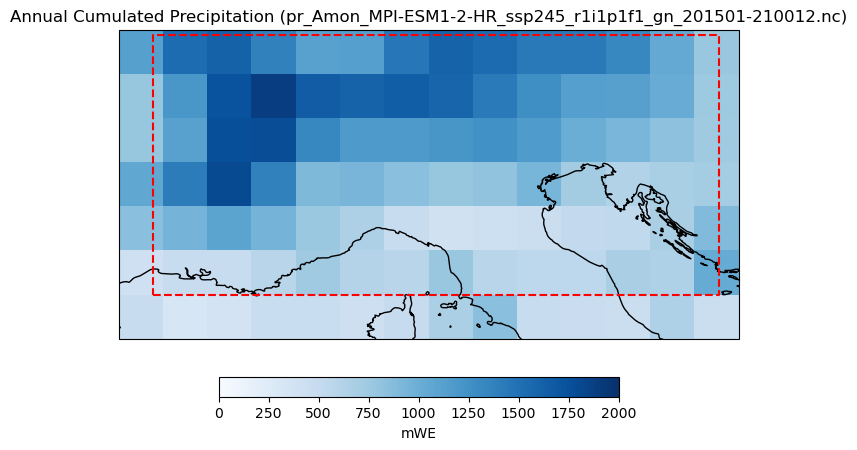

In [12]:
### First plot as a test (mean Temperature)

# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

### --- Prec in kg m-2 Y-1 --- ###
### --- sum kg m-2 s-1 * 3600 (s h-1)*24 (h j-1) *30 (j M-1)/85 (2100-2015 = 85 Years) --- ###

# pcolormesh
m = ax.pcolormesh(
    longG, latiG, dsGCM.pr.sum("time")[jmin:jmax,imin:imax]*3600*24*30/85, #Mean Annual Precipitation
    cmap=colo_scale , vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
       

    #ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
ax.add_feature(cfeature.COASTLINE)
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
#for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    #ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='mWE') # label=f'{dsGCM.pr.units}'*

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Annual Cumulated Precipitation ({JustFilename})')

In [13]:
years=np.zeros(last_year-first_year+1)
# TTz
T_month = np.zeros(((last_year-first_year+1),12,(jmax-jmin),(imax-imin)))
T_season= np.zeros(((last_year-first_year+1), 4,(jmax-jmin),(imax-imin)))
T_year  = np.zeros(((last_year-first_year+1),   (jmax-jmin),(imax-imin)))

T_month.shape # 4 dimensions : year, month, lat, lon #  (86, 12, 5, 8) ?

(86, 12, 7, 14)

In [14]:
years = np.arange(first_year,last_year+1)

### 2.1 First method 1 : loops ij to reshape the array

### 2.2 2nd method with xarray

In [24]:
T_month2 = np.zeros(((last_year-first_year+1),12,(jmax-jmin),(imax-imin)))
T_season2= np.zeros(((last_year-first_year+1), 4,(jmax-jmin),(imax-imin)))
T_year2  = np.zeros(((last_year-first_year+1),   (jmax-jmin),(imax-imin)))

In [33]:
grouped = dsGCM.groupby('time.year')
# Extract 2D values for each month (1-12) for every year
monthly_data = {}
for year, group in grouped:
    # Select data for all 12 months in the current year
    monthly_data[year] = group.groupby('time.month').mean('time')
    # If you want the raw values instead of the mean, use:
    # monthly_data[year] = group.groupby('time.month')

# Combine all years and months into a single DataArray
all_months = xr.concat([monthly_data[year] for year in monthly_data], dim='year')
#all_months = all_months.transpose('year', 'month', ...)  # Adjust dimensions as needed

T_month2=all_months.pr[:,:,jmin:jmax,imin:imax]

In [44]:
T_month2.shape

(86, 12, 7, 14)

In [46]:
T_season2[:,0] = dsGCM.pr[:,jmin:jmax,imin:imax].sel(time=dsGCM.pr.time.dt.season=="DJF").groupby("time.year").mean("time")
T_season2[:,1] = dsGCM.pr[:,jmin:jmax,imin:imax].sel(time=dsGCM.pr.time.dt.season=="MAM").groupby("time.year").mean("time")
T_season2[:,2] = dsGCM.pr[:,jmin:jmax,imin:imax].sel(time=dsGCM.pr.time.dt.season=="JJA").groupby("time.year").mean("time") 
T_season2[:,3] = dsGCM.pr[:,jmin:jmax,imin:imax].sel(time=dsGCM.pr.time.dt.season=="SON").groupby("time.year").mean("time")
#DJF_tas_MPI245

In [47]:
T_year2[:] = dsGCM.pr[:,jmin:jmax,imin:imax].groupby("time.year").mean("time")

Text(0.5, 1.0, 'Season 0 Culumated Precipitation (2015) Method 2')

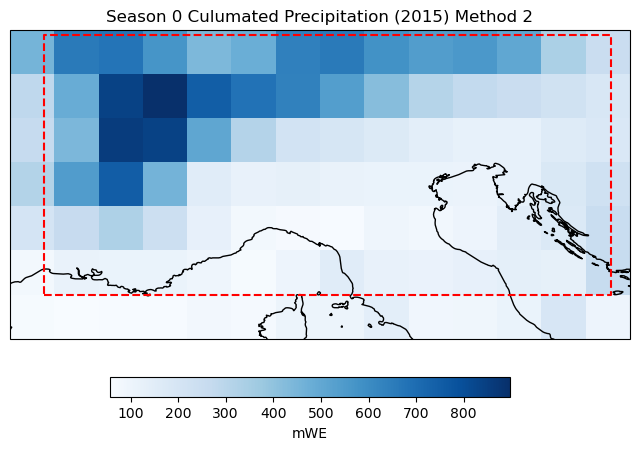

In [48]:
# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    longG, latiG, T_season2[0,0]*3600*24*30*3, #,
    cmap=colo_scale)#, vmin=vmin_scale, vmax=vmax_scale, shading='auto')

#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
ax.add_feature(cfeature.COASTLINE)
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
#for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    #ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='mWE')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Season 0 Culumated Precipitation ({first_year}) Method 2')

Text(0.5, 1.0, 'Precipitation, sum 4 seasons (2015) Method 2')

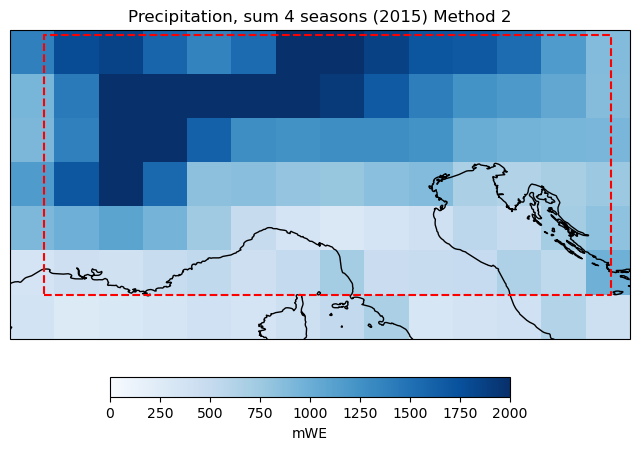

In [49]:
# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    longG, latiG, sum(T_season2[0,:])*3600*24*30*3, #T_season[0,0]-273.15,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto')

#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
ax.add_feature(cfeature.COASTLINE)
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
#for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    #ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='mWE')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Precipitation, sum 4 seasons ({first_year}) Method 2')

### 2.3 check if the different methods give the same result (seasonnal)

Text(0.5, 0.98, 'Mean seasonal precipitation by 2 methods (MPI SSP245)')

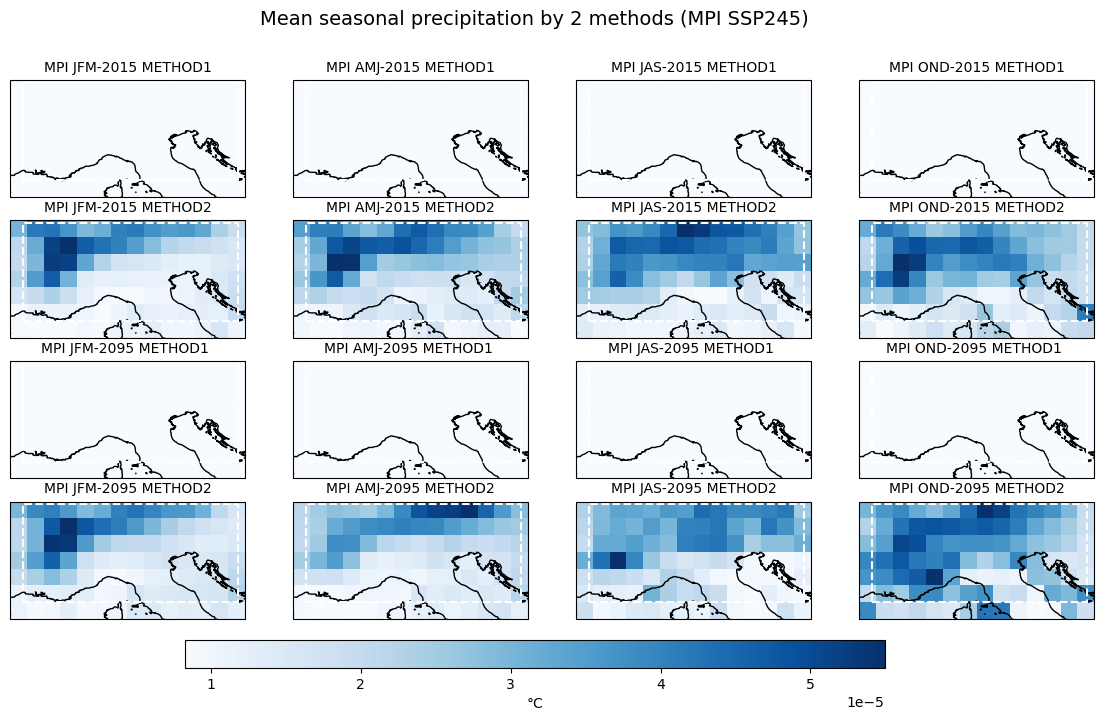

In [50]:
y1, y2 = 0, 80
# Plot temperature pour 4 glacier
proj = ccrs.PlateCarree()
quality = 100

fig, axs = plt.subplots(4, 4, figsize=(14, 7),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

saisons=['JFM','AMJ','JAS','OND']
             
for i in range(len(saisons)):
    #print(i,saisons[i])
    # ----- GCM METHOD1 Firt year -----
    ax = axs[0, i]
    ax.set_title(f"MPI {saisons[i]}-{y1+2015} METHOD1",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, T_season[y1,i],
    cmap=colo_scale)#, vmin=vmin_scale, vmax=vmax_scale, shading='auto' )
    
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- GCM METHOD2 Firt year -----
    ax = axs[1, i]
    ax.set_title(f"MPI {saisons[i]}-{y1+2015} METHOD2",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, T_season2[y1,i],
    cmap=colo_scale)#, vmin=vmin_scale, vmax=vmax_scale, shading='auto' )
    
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    
    # ----- GCM METHOD1 Later -----
    ax = axs[2, i]
    ax.set_title(f"MPI {saisons[i]}-{y2+2015} METHOD1 ",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, T_season[y2,i],
    cmap=colo_scale)#, vmin=vmin_scale, vmax=vmax_scale, shading='auto' )
    
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- GCM METHOD2 Later -----
    ax = axs[3, i]
    ax.set_title(f"MPI {saisons[i]}-{y2+2015} METHOD2",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, T_season2[y2,i],
    cmap=colo_scale)#, vmin=vmin_scale, vmax=vmax_scale, shading='auto' )
    
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    
# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

fig.suptitle("Mean seasonal precipitation by 2 methods (MPI SSP245)", fontsize=14)

### 2.3 Save

In [51]:
filout = 'numpyData/prec_'+name_GCM+'_'+scenario
np.savez(filout,T_month=T_month2,T_season=T_season2,T_year=T_year2,lon=longG,lat=latiG,years=years)
print(years)
print(filout)

[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028
 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042
 2043 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054 2055 2056
 2057 2058 2059 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070
 2071 2072 2073 2074 2075 2076 2077 2078 2079 2080 2081 2082 2083 2084
 2085 2086 2087 2088 2089 2090 2091 2092 2093 2094 2095 2096 2097 2098
 2099 2100]
numpyData/prec_MPI-ESM1-2-HR_ssp245


## 3. Save MAR MPI

In [ ]:
scenario = 'SSP245' #'HIST' #'SSP245' #'SSP585' # MAR
# Information on the first file
year=first_year
#file1=path_MAR+'/'+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_'+scenario+'.'+sim+'.TTz.'+str(year)+'.nc'

file1=path_MARSIMU+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+nameGCMinMARfile+'_'+scenario+'.'+simSSP+'.MBsf.'+str(year)+'.nc'
file2=path_MARSIMU+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+nameGCMinMARfile+'_'+scenario+'.'+simSSP+'.MBrr.'+str(year)+'.nc'
#file1='/bettik/peyaudv/MAR_GCMs/GCM/EC-Earth3/tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_201501-201512_EU.nc '
print(file1)
print(file2)
ds1 = xr.open_dataset(file1) # snow fall
ds2 = xr.open_dataset(file2) # rain
#ds

In [ ]:
ds1.MBsf

Mail maria.santolaria-otin 26/02/26

Pour simus MAR-HMA, les fichiers journalières ce sont le cumul de précipitation horaires (le raw output), 
donc on a mm/jour.

Pour le fichier mensuel, moi, je fais la moyenne de tous le jours du mois, 
donc cest mm/jour aussi.

In [ ]:
ds1.MBsf
ds2.MBrr
precip = ds1.MBsf + ds2.MBrr
#aa

In [ ]:
snow = ds1.MBsf
rain = ds2.MBrr

In [ ]:
snow.values[0,:,:]

In [ ]:
rain.values[0,:,:]

In [ ]:
precip[0,:,:]

In [ ]:
season_mean(precip)

In [ ]:
# Topo MAR
dsTopo = xr.open_dataset(path_MAR+'MAR-ERA-20C/MARgrid_EUf.nc')

imin = 32 ; imax = -30
jmin = 20 ; jmax = -15
longM = dsTopo.LON[jmin:jmax,imin:imax]
latiM = dsTopo.LAT[jmin:jmax,imin:imax]

# Surface Altitude
altiM = dsTopo.SH[jmin:jmax,imin:imax]

In [ ]:
#dsTopo.LON[jmin:jmax,0]

In [ ]:
dsTopo.LON.shape

In [ ]:
dsTopo.LON[jmin:jmax,imin:imax].shape

In [ ]:
longM.shape

In [ ]:
# Proj
proj = ccrs.PlateCarree()
quality = 100
vmin_scale, vmax_scale = 0, 2000 


fig, axs = plt.subplots(2, 2, figsize=(12, 6),subplot_kw={'projection': proj})

axs.ravel()


m = axs[0][0].pcolormesh(
    longM, latiM, ds1.MBsf.sum("time")[jmin:jmax,imin:imax]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto'

axs[0][1].pcolormesh(
    longM, latiM, ds2.MBrr.sum("time")[jmin:jmax,imin:imax]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto'

axs[1][0].pcolormesh(
    longM, latiM, ds1.MBsf.sum("time")[jmin:jmax,imin:imax]*30.5+ds2.MBrr.sum("time")[jmin:jmax,imin:imax]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto'

axs[1][1].pcolormesh(
    longM, latiM, precip.sum("time")[jmin:jmax,imin:imax]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto'

axs[0][0].set_title('MAR Snow Fall', fontsize=10)
axs[0][1].set_title('MAR Rain Fall', fontsize=10)
axs[1][0].set_title('MAR Snow + Rain', fontsize=10)
axs[1][1].set_title('Saved Data', fontsize=10)

for i in range(len(axs)):
    for j in range(len(axs[0])):
        ax = axs[i][j]
        #ax = plt.axes(projection=ccrs.PlateCarree())
        #ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
        ax.add_feature(cfeature.COASTLINE)
        # Tracé du polygone en pointillés rouge
        ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
        

#axs[0][0] = plt.axes(projection=ccrs.PlateCarree())

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='mmWE')

fig.suptitle(f'Cumuled Precipitation ({JustFilename})')
plt.savefig(f"{path_IMG}MAR_{name_GCM}_Cumuled_Precipitation_{JustFilename[:-3]}.png")
# Information on the first file
year=first_year

In [ ]:
years=np.zeros(last_year-first_year+1)
# TTz
T_month = np.zeros(((last_year-first_year+1),12,91,139))
T_season= np.zeros(((last_year-first_year+1), 4,91,139))
T_year  = np.zeros(((last_year-first_year+1)   ,91,139))
# 4 dimensions : year, month, AND lon, lat ???  
T_month.shape

In [ ]:
# Open files and copy data in Arrays T_month and T_season (for months and saisons data)
for year in list(range(first_year,last_year+1)):
    print(year,end=' ')
    #if year == 1985 or year == 2071:
    #    continue
       # file1=path_MARSIMU+'/'+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_'+scenario+'.'+sim+'.TTz.'+str(year)+'.nc'
    hist_path1 = path_MARSIMU+'/HIST/'+data_freq+'/'+data_freq_prefix+'.'+nameGCMinMARfile+'_HIST.'+simHIST+'.MBsf.'+str(year)+'.nc'
    ssp245_path1 = path_MARSIMU+'/SSP245/'+data_freq+'/'+data_freq_prefix+'.'+nameGCMinMARfile+'_SSP245.'+simSSP+'.MBsf.'+str(year)+'.nc'
    hist_path2 = path_MARSIMU+'/HIST/'+data_freq+'/'+data_freq_prefix+'.'+nameGCMinMARfile+'_HIST.'+simHIST+'.MBrr.'+str(year)+'.nc'
    ssp245_path2 = path_MARSIMU+'/SSP245/'+data_freq+'/'+data_freq_prefix+'.'+nameGCMinMARfile+'_SSP245.'+simSSP+'.MBrr.'+str(year)+'.nc'
    if year <2015:
        ds_var1 = xr.open_dataset(hist_path1)
        ds_var2 = xr.open_dataset(hist_path2)
    else:
        #ds_T = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/monthly/MON.EC-Earth3_SSP245.EUe.TTz.'+str(year)+'.nc')
        ds_var1 = xr.open_dataset(ssp245_path1)
        ds_var2 = xr.open_dataset(ssp245_path2)
        #print("ssp245_path")
    ds_var=ds_var1.MBsf+ds_var2.MBrr
    T_month[year-first_year]=ds_var[:,jmin:jmax,imin:imax]
    T_season[year-first_year]=season_sum(ds_var).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))[:,jmin:jmax,imin:imax]
    T_year[year-first_year]=ds_var[:,jmin:jmax,imin:imax].sum("time")
    
    seasonal_mean_year=season_sum(ds_var).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))
    years[year-first_year]=year
    
   # T_year2[:] = dsGCM.tas[:,jmin:jmax,imin:imax].groupby("time.year").mean("time") - 273.16

In [ ]:
print(T_year[0])

In [ ]:
print(T_month[0])

In [ ]:
filout = 'numpyData/prec_'+'MAR'+name_GCM+'_'+scenario
np.savez(filout,T_month=T_month,T_season=T_season,T_year=T_year,lon=longM,lat=latiM,years=years)
print(filout)

In [ ]:
# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    longM, latiM, T_year[0]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto')

#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
ax.add_feature(cfeature.COASTLINE)
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
#for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    #ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='mWE')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Cumuled all Precipitation ({first_year})')
plt.savefig(f"{path_IMG}MAR_{name_GCM}_Precip_Ann_saved_{scenario}_{first_year}.png")



In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 4))

# Création d'une grille 2 lignes x 3 colonnes
gs = gridspec.GridSpec(2, 3, width_ratios=[2, 1, 1])

# Grand subplot à gauche (prend les 2 lignes de la première colonne)
ax_big = fig.add_subplot(gs[:, 0], projection=proj)

# 4 petits subplots à droite (2x2)
ax1 = fig.add_subplot(gs[0, 1], projection=proj)
ax2 = fig.add_subplot(gs[0, 2], projection=proj)
ax3 = fig.add_subplot(gs[1, 1], projection=proj)
ax4 = fig.add_subplot(gs[1, 2], projection=proj)


m = ax_big.pcolormesh(
    longM, latiM, T_season[0,0]*30.5+T_season[0,1]*30.5+T_season[0,2]*30.5+T_season[0,3]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto'


ax1.pcolormesh(
    longM, latiM, T_season[0,0]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto'

ax2.pcolormesh(
    longM, latiM, T_season[0,1]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto'

ax3.pcolormesh(
    longM, latiM, T_season[0,2]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto'

ax4.pcolormesh(
    longM, latiM, T_season[0,3]*30.5,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)#, shading='auto'

for ax in ax_big, ax1, ax2, ax3, ax4:
    #ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
    ax.add_feature(cfeature.COASTLINE)
    # Tracé du polygone en pointillés rouge
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

axes = [ax_big, ax1, ax2, ax3, ax4]
label= ["annual (DJF+MAM+JJA+SON)", "DJF", "MAM", "JJA", "SON"]

for i, ax in enumerate([ax_big, ax1, ax2, ax3, ax4]):
    ax.set_title(label[i])
# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, -0.02, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='mWE')

plt.tight_layout()

plt.savefig(f"{path_IMG}MAR_{name_GCM}_Precip_Cumul_and_by_season_{scenario}_{first_year}.png")


## 4. Save MAR Topo

In [ ]:
#filout = 'numpyData/topo_MAR_SurfaceH'
#np.savez(filout,SH=altiM)
#print(filout)